# 📊 Customer Churn Prediction — Analyse Exploratoire des Données (EDA)

---

## 🎯 Objectif de ce Notebook

Ce notebook constitue la **première phase** du projet de prédiction du désabonnement client (*Customer Churn*). Il a pour but de **comprendre en profondeur les données** avant toute modélisation, à travers :

- L'inspection de la structure et de la qualité des données
- L'analyse statistique des variables numériques et catégorielles
- La visualisation des distributions et des relations avec la variable cible `Churn`
- L'identification des **indicateurs clés** susceptibles d'influencer le comportement de désabonnement

---

## 🔧 Étape 1 — Importation des Bibliothèques

Nous importons les bibliothèques scientifiques nécessaires pour la manipulation des données et la visualisation :

| Bibliothèque | Rôle |
|---|---|
| `pandas` | Manipulation et analyse des données sous forme de tableaux (DataFrames) |
| `numpy` | Calculs numériques avancés et opérations matricielles |
| `matplotlib` | Création de graphiques de base |
| `seaborn` | Visualisation statistique avancée, basée sur matplotlib |
| `sklearn` | Bibliothèque de Machine Learning pour la préparation des données |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

## 📁 Étape 2 — Chargement des Données

Nous chargeons le dataset **Telco Customer Churn** fourni par IBM Watson Analytics. Ce jeu de données contient des informations sur les clients d'une entreprise de télécommunications et indique si chaque client a résilié son abonnement (`Churn = Yes`) ou non (`Churn = No`).

**Caractéristiques du dataset :**
- **7 043 clients** (lignes)
- **21 variables** (colonnes) : informations démographiques, services souscrits, informations de facturation et statut de désabonnement


In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 🏢 Customer Churn Prediction

---

## 💼 Problème Métier

Le **désabonnement client** (*Customer Churn*) représente la perte de clients qui mettent fin aux services d'une entreprise. C'est l'un des défis les plus critiques dans le secteur des télécommunications.

> 📌 **Fait clé :** Acquérir un nouveau client coûte en moyenne **5 à 7 fois plus cher** que de conserver un client existant. Il est donc stratégiquement crucial d'identifier les clients à risque *avant* qu'ils ne partent.

---

## 🎯 Objectif du Projet

Développer des modèles de **Machine Learning** et de **Deep Learning** capables de prédire si un client est susceptible de quitter l'entreprise.

Le modèle final permettra à l'entreprise de :
- 🔍 **Identifier** les clients à risque élevé de désabonnement
- 💡 **Mettre en place** des stratégies de rétention proactives (offres personnalisées, suivi dédié)
- 💰 **Réduire** les pertes financières liées au churn


## 🔍 Étape 3 — Inspection Initiale des Données

### `df.head()` — Aperçu des premières lignes

Cette commande affiche les **5 premières lignes** du DataFrame. Elle nous permet de :
- Vérifier que le fichier a été chargé correctement
- Observer la structure générale des colonnes et le type de données contenues
- Identifier visuellement les premières anomalies ou incohérences


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### `df.shape` — Dimensions du dataset

Retourne un tuple `(nombre de lignes, nombre de colonnes)`. Cela nous confirme la **taille exacte** du dataset sur lequel nous allons travailler : **7 043 clients** et **21 colonnes** (features + variable cible).


In [4]:
df.shape

(7043, 21)

### `df.info()` — Types de données et valeurs manquantes

Cette méthode est essentielle car elle affiche pour chaque colonne :
- Le **type de données** (`int64`, `float64`, `object`)
- Le **nombre de valeurs non-nulles** (ce qui permet de détecter des valeurs manquantes)
- La **mémoire utilisée** par le DataFrame

> ⚠️ **Observation importante :** La colonne `TotalCharges` est de type `object` alors qu'elle devrait être numérique. Cela signifie qu'elle contient probablement des espaces vides (`' '`) qui empêchent la conversion automatique. Ce point sera corrigé dans le notebook de prétraitement.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### `df.describe()` — Statistiques descriptives

Fournit un résumé statistique des **colonnes numériques** : count, moyenne, écart-type, min, max et quartiles (25%, 50%, 75%).

**Interprétation des variables numériques :**
| Variable | Interprétation |
|---|---|
| `SeniorCitizen` | Variable binaire (0 = non senior, 1 = senior). Moyenne ≈ 0.16 → seulement 16% de seniors |
| `tenure` | Ancienneté du client en mois. La médiane est ~29 mois (≈ 2.5 ans) |
| `MonthlyCharges` | Charges mensuelles entre 18.25$ et 118.75$, avec une médiane de 70.35$ |


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---

## 🧹 Étape 4 — Vérification des Valeurs Manquantes

Avant toute analyse, il est indispensable de s'assurer que le dataset ne contient pas de **valeurs manquantes** (`NaN`), car elles peuvent fausser les analyses statistiques et les modèles d'apprentissage automatique.

Nous utilisons deux approches complémentaires :
1. **`df.isnull().sum()`** → Compte le nombre de valeurs nulles par colonne
2. **Heatmap Seaborn** → Visualisation graphique des valeurs manquantes (les zones blanches indiquent des NaN)

> ✅ **Résultat attendu :** Aucune valeur manquante n'est visible directement, mais `TotalCharges` contient des chaînes vides qui seront converties en `NaN` lors du prétraitement.


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


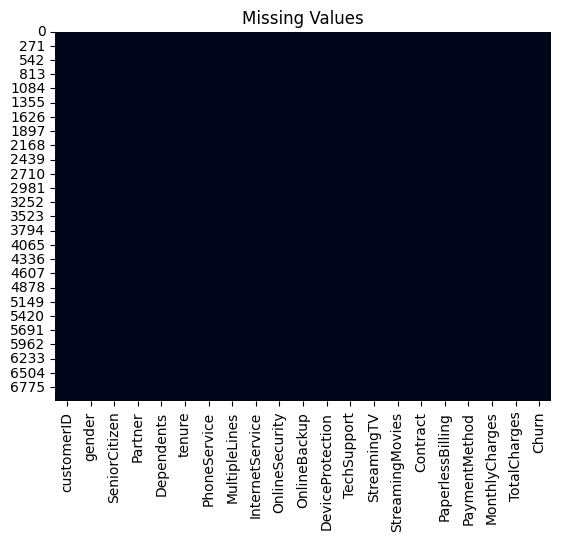

In [8]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

---

## 🎯 Étape 5 — Analyse de la Variable Cible : `Churn`

La variable cible `Churn` est une **variable binaire** :
- `No` (0) → Le client est resté
- `Yes` (1) → Le client a quitté l'entreprise

### Déséquilibre des Classes (Class Imbalance)

L'analyse de la distribution de `Churn` révèle un **déséquilibre significatif** :
- **~73%** des clients n'ont pas churné (`No`)
- **~27%** des clients ont churné (`Yes`)

> ⚠️ **Impact sur la modélisation :** Ce déséquilibre signifie qu'un modèle naïf qui prédirait toujours `No` aurait une accuracy apparente de 73%. Il faut donc utiliser des métriques adaptées comme le **ROC-AUC**, le **Recall** et le **F1-Score** plutôt que la simple Accuracy.


In [9]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


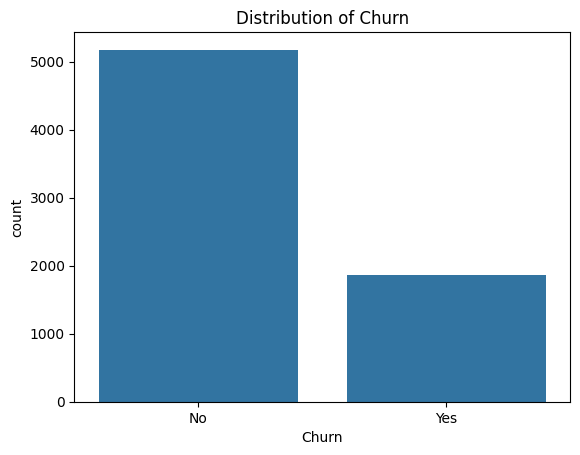

In [10]:
sns.countplot(data=df, x="Churn")
plt.title("Distribution of Churn")
plt.show()

### 7.2 — Churn selon l'Ancienneté (`tenure`)

Le graphique en boîtes (*boxplot*) compare la distribution de l'ancienneté entre les clients qui ont churné et ceux qui sont restés.

**Interprétation :**
- Les clients qui **ont churné** ont une ancienneté médiane très **faible** (≈ 10 mois)
- Les clients qui **sont restés** ont une ancienneté médiane beaucoup plus **élevée** (≈ 38 mois)

> 💡 **Insight clé :** Les **nouveaux clients** (tenure < 12 mois) sont les plus vulnérables au churn. Une stratégie d'onboarding renforcée pour les 6 premiers mois pourrait réduire significativement le taux de désabonnement.


In [ ]:
Analyse des variables numériques

In [11]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

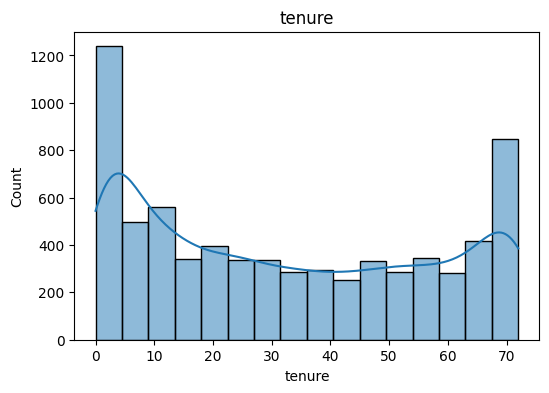

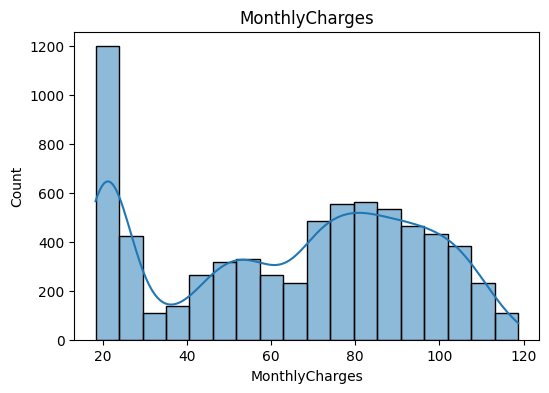

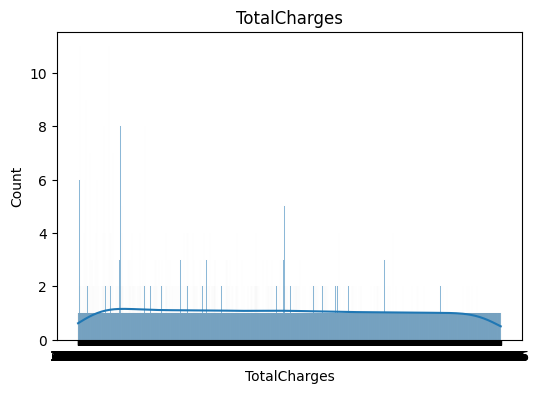

In [12]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

### 7.4 — Taux de Churn par Variable Catégorielle

Nous calculons et visualisons le **taux de churn normalisé** pour chaque modalité des variables catégorielles. Les graphiques empilés (*stacked bar charts*) montrent la proportion de clients churned vs non-churned pour chaque catégorie.

**Variables analysées :**
- `gender` — Le genre (peu d'impact sur le churn)
- `Partner` — Avoir un(e) partenaire (les célibataires churns plus)
- `Dependents` — Avoir des personnes à charge (les clients avec dépendants churns moins)
- `InternetService` — Type d'internet (la fibre optique → taux de churn plus élevé)
- `Contract` — Type de contrat (mensuel → churn élevé)
- `PaymentMethod` — Mode de paiement (chèque électronique → churn plus élevé)


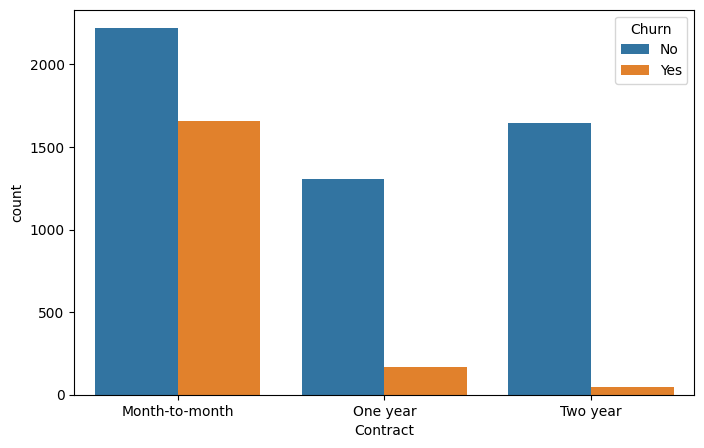

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x='Contract',
              hue='Churn')
plt.show()

### 7.2 — Churn selon l'Ancienneté (`tenure`)

Le graphique en boîtes (*boxplot*) compare la distribution de l'ancienneté entre les clients qui ont churné et ceux qui sont restés.

**Interprétation :**
- Les clients qui **ont churné** ont une ancienneté médiane très **faible** (≈ 10 mois)
- Les clients qui **sont restés** ont une ancienneté médiane beaucoup plus **élevée** (≈ 38 mois)

> 💡 **Insight clé :** Les **nouveaux clients** (tenure < 12 mois) sont les plus vulnérables au churn. Une stratégie d'onboarding renforcée pour les 6 premiers mois pourrait réduire significativement le taux de désabonnement.


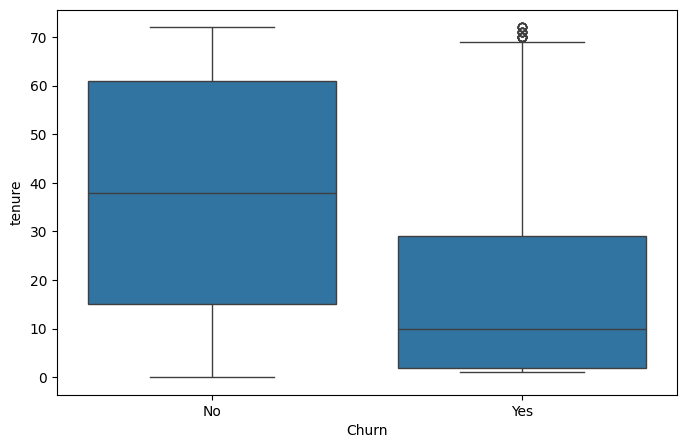

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='Churn',
            y='tenure')
plt.show()

### 7.3 — Churn selon les Charges Mensuelles (`MonthlyCharges`)

Ce boxplot compare les charges mensuelles selon le statut de churn.

**Interprétation :**
- Les clients qui ont churné ont des **charges mensuelles plus élevées** en médiane
- Cela suggère que les clients qui paient plus cher par mois sont plus sensibles aux offres concurrentes

> 💡 **Insight clé :** Un tarif perçu comme trop élevé par rapport à la valeur reçue est un facteur déclencheur de churn. Des offres de fidélisation ciblées sur les clients à tarif élevé pourraient être efficaces.


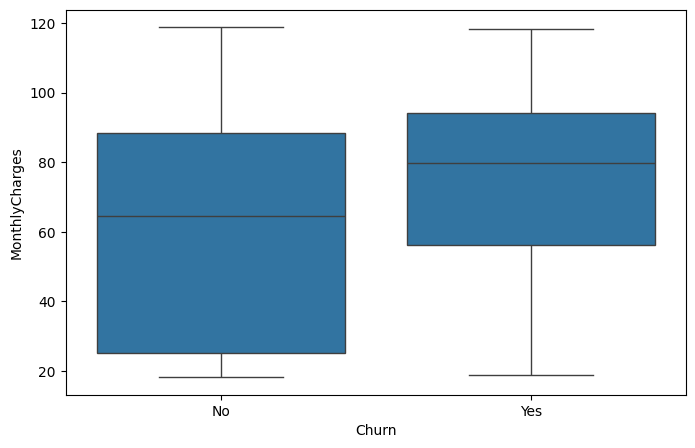

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='Churn',
            y='MonthlyCharges')
plt.show()

### 7.4 — Taux de Churn par Variable Catégorielle

Nous calculons et visualisons le **taux de churn normalisé** pour chaque modalité des variables catégorielles. Les graphiques empilés (*stacked bar charts*) montrent la proportion de clients churned vs non-churned pour chaque catégorie.

**Variables analysées :**
- `gender` — Le genre (peu d'impact sur le churn)
- `Partner` — Avoir un(e) partenaire (les célibataires churns plus)
- `Dependents` — Avoir des personnes à charge (les clients avec dépendants churns moins)
- `InternetService` — Type d'internet (la fibre optique → taux de churn plus élevé)
- `Contract` — Type de contrat (mensuel → churn élevé)
- `PaymentMethod` — Mode de paiement (chèque électronique → churn plus élevé)


In [16]:
categorical_columns = [
    'gender',
    'Partner',
    'Dependents',
    'InternetService',
    'Contract',
    'PaymentMethod'
]

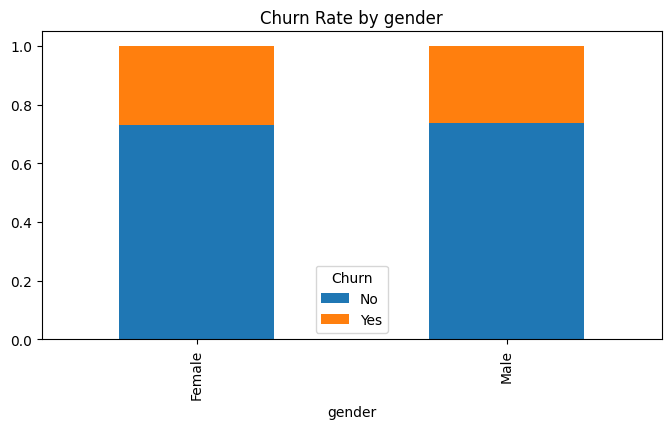

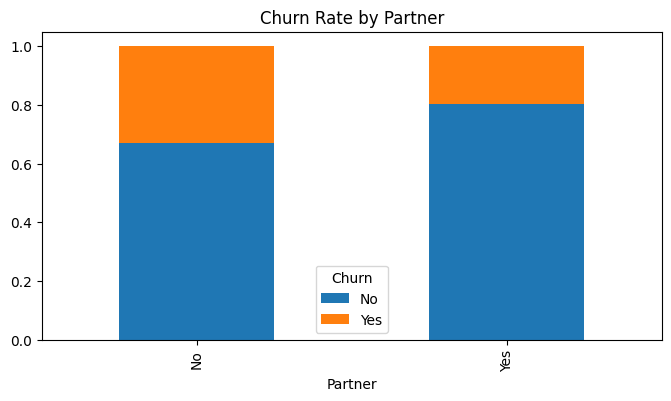

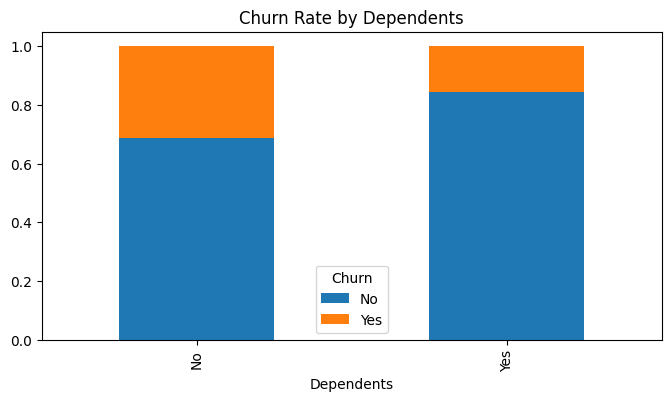

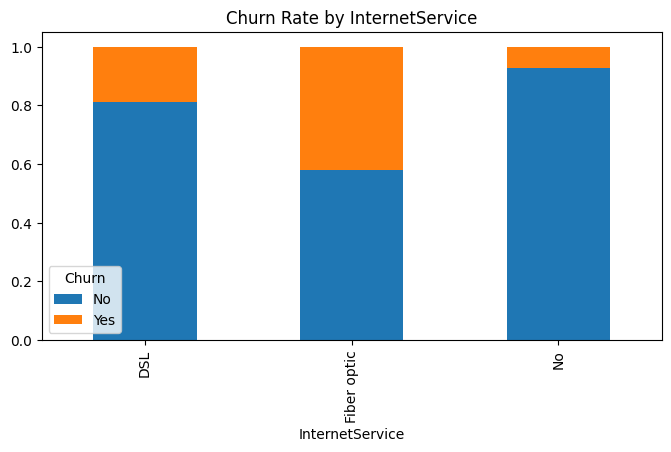

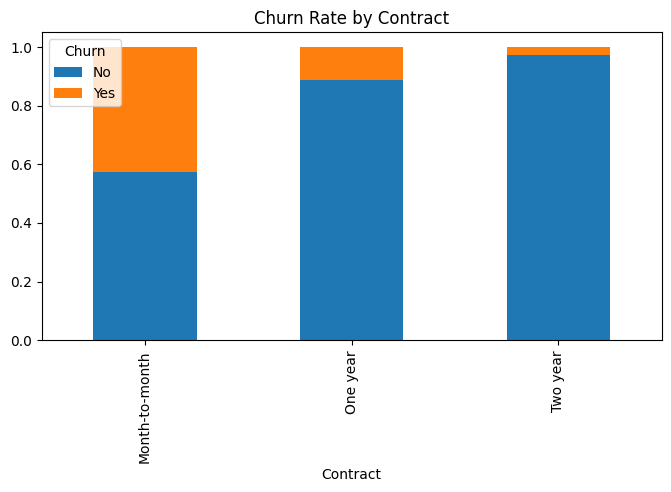

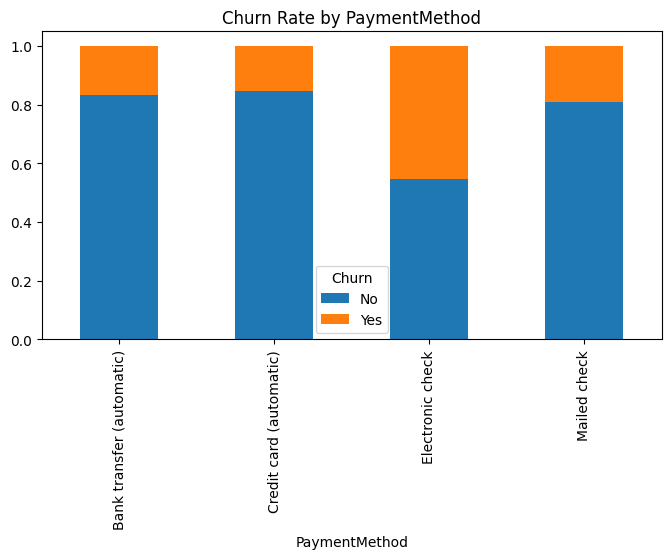

In [17]:
for col in categorical_columns:
    churn_rate = pd.crosstab(
        df[col],
        df['Churn'],
        normalize='index'
    )

    churn_rate.plot(
        kind='bar',
        stacked=True,
        figsize=(8,4)
    )

    plt.title(f"Churn Rate by {col}")
    plt.show()

---

## 📋 Synthèse de l'Analyse Exploratoire — Conclusions Clés

L'EDA nous a permis de dégager les **5 enseignements principaux** suivants :

| # | Facteur de Risque | Observation |
|---|---|---|
| 1 | 📄 **Type de Contrat** | Les clients avec un contrat **mois à mois** présentent le taux de churn le plus élevé (~42%). C'est la variable la plus discriminante. |
| 2 | ⏱️ **Ancienneté** | Les clients avec une ancienneté **courte** (< 12 mois) sont les plus susceptibles de partir. Les clients fidèles restent. |
| 3 | 💳 **Charges Mensuelles** | Des charges mensuelles **élevées** sont corrélées à un taux de churn plus important. |
| 4 | 🌐 **Type d'Internet** | Les clients avec la **fibre optique** churns plus que ceux avec le DSL ou sans internet. |
| 5 | 🔑 **Variables Prédictives** | `Contract`, `tenure`, `MonthlyCharges` et `InternetService` seront très probablement les variables les plus importantes dans nos modèles ML. |

---

> ➡️ **Prochaine étape :** Le notebook `2Preprocessing.ipynb` va nettoyer, encoder et préparer ces données pour l'entraînement des modèles de Machine Learning et Deep Learning.
